# Data

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import torch

# Data
X, y = make_classification(n_samples=5000, n_features=20, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
X_train_val_cal, X_test, y_train_val_cal, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_val, X_cal, y_train_val, y_cal = train_test_split(X_train_val_cal, y_train_val_cal, test_size=0.2, random_state=42)

# Architectures

In [2]:
from torch import nn
from typing import Literal

class MLPClassifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, input_dim:int, output_dim:int, activation:Literal['ReLU', 'Tanh'] = 'ReLU'):
        super(MLPClassifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        if activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(f"Unknown activation function: {activation}")

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x.squeeze(1) if x.shape[-1] == 1 else x

In [3]:
import torch
from torch import nn

class TemperatureScaler(nn.Module):
    def __init__(self, model):
         super().__init__()
         self.model = model
         model.eval()
         self.temperature = nn.Parameter(torch.ones(1)) # T

    def forward(self, x):
        with torch.no_grad():
            logits = self.model(x)

        return logits / self.temperature

def fit_temperature(model, X_val, y_val):
    scaler = TemperatureScaler(model).to(DEVICE)
    optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.01, max_iter=15000)
    criterion = nn.BCEWithLogitsLoss()

    def closure():
        optimizer.zero_grad()
        logits = scaler(X_val)
        loss = criterion(logits, y_val)
        loss.backward()

        return loss

    optimizer.step(closure)
    return scaler

# Prediction
and loading models

In [7]:
import torch
import os

write_model_dir = os.path.join('Models', 'no_cal')
write_scaler_path = os.path.join('Models', 'scaler')



DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Model Parameters
model_parameter = {
    'n_hidden': 3,
    'hidden_dim': 64,
    'input_dim':X_train_val.shape[1],
    'output_dim':1
}

probs = {
    'before':[],
    'after':[]
}

scalers = []
for idx in range(5):
    m = MLPClassifier(**model_parameter).to(DEVICE)
    m.load_state_dict(torch.load(os.path.join(write_model_dir, f"fold_{idx}.pth")))

    scaler = TemperatureScaler(m).to(DEVICE)
    scaler.load_state_dict(torch.load(os.path.join(write_scaler_path, f"fold_{idx}.pth")))
    scalers.append(scaler)

    # Before calibration
    logits = m(X_test.to(DEVICE)).detach()
    probs_before = torch.sigmoid(logits).cpu().numpy()

    # After temperature scaling
    logits_scaled = scaler(X_test.to(DEVICE)).detach()
    probs_after = torch.sigmoid(logits_scaled).cpu().numpy()

    probs['before'].append(probs_before)
    probs['after'].append(probs_after)

## Prediction

In [15]:
import numpy as np

def mean_response_ensemble(probs_list, threshold=0.5):
    if not probs_list:
        raise ValueError("Lista prawdopodobieństw nie może być pusta.")

    mean_probs = np.mean(probs_list, axis=0)
    preds = (mean_probs >= threshold).astype(int)

    return preds, mean_probs

preds = {
    'after': mean_response_ensemble(probs['after'], threshold=0.5)[0],
    'before': mean_response_ensemble(probs['before'], threshold=0.5)[0]
}

# Testing

## McNemar

In [20]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from utils8.Predictor import Predictor


y_test_np = y_test.numpy()
# 2. Calculate the outcomes (Correct vs Incorrect)
after_cal = (preds['after'] == y_test_np)
before_cal = (preds['before'] == y_test_np)

# 3. Build the 2x2 Contingency Table
# True/True, True/False, False/True, False/False
a = np.sum(after_cal & before_cal)
b = np.sum(after_cal & ~before_cal)
c = np.sum(~after_cal & before_cal)
d = np.sum(~after_cal & ~before_cal)

table = [[a, b],
         [c, d]]

print("Contingency Table:")
print(f"[{a}, {b}]")
print(f"[{c}, {d}]\n")

# 4. Perform McNemar's Test
# exact=False uses the Chi-Squared distribution (good for large samples)
# correction=True applies Edwards' continuity correction
result = mcnemar(table, exact=False, correction=True)

# 5. Interpret Results
print(f"Statistic: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4e}")

alpha = 0.05
if result.pvalue < alpha:
    print("Conclusion: Reject the null hypothesis. There is a statistically significant difference between the two ensemble models.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference between the two ensemble models.")

Contingency Table:
[863, 1]
[0, 136]

Statistic: 0.0000
P-value: 1.0000e+00
Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference between the two ensemble models.


# Rozkłady Prawdobodpobieństwa, Niepewność epistemiczna i aletoryczna

Kiedy korzystamy z zespołu modeli (*Ensemble*), możemy rozbić całkowitą niepewność predykcji na dwa składowe komponenty: **aleatoryczną** (szum w danych) oraz **epistemiczną** (brak wiedzy modelu).

## Wzory Matematyczne

Dla zespołu składającego się z $M$ modeli, gdzie $p_m$ oznacza prawdopodobieństwo klasy pozytywnej zwrócone przez $m$-ty model, a $\bar{p}$ to średnie prawdopodobieństwo całego zespołu:

* **Entropia binarna (miara chaosu dla pojedynczego prawdopodobieństwa $p$):**
  $$H(p) = -p \log_2(p) - (1 - p) \log_2(1 - p)$$

* **Niepewność Całkowita (Total Uncertainty):**
  $$U_{tot} = H(\bar{p})$$
  *(Entropia wyliczona ze średniego prawdopodobieństwa zespołu)*

* **Niepewność Aleatoryczna (Aleatoric Uncertainty):**
  $$U_{ale} = \frac{1}{M} \sum_{m=1}^{M} H(p_m)$$
  *(Średnia arytmetyczna z entropii poszczególnych modeli)*

* **Niepewność Epistemiczna (Epistemic Uncertainty):**
  $$U_{epi} = U_{tot} - U_{ale}$$
  *(Różnica między niepewnością całkowitą a aleatoryczną – tzw. Informacja Wzajemna)*


In [25]:
import numpy as np
import torch

def calculate_uncertainties(probs_list):
    """
    Oblicza całkowitą, aleatoryczną i epistemiczną niepewność dla klasyfikacji binarnej.

    Parametry:
    - probs_list: Lista tablic/tensorów z prawdopodobieństwami z M modeli.
                  Każdy element ma kształt (n_samples,).
    """

    # Zamieniamy listę w macierz (M_models, n_samples)
    probs_matrix = np.stack(probs_list, axis=0)

    # Mała stała stabilizująca, zapobiegająca log(0)
    eps = 1e-12

    # Pomocnicza funkcja do liczenia entropii binarnej
    def binary_entropy(p):
        p = np.clip(p, eps, 1.0 - eps) # przycinanie wartości do bezpiecznego przedziału
        return -p * np.log2(p) - (1.0 - p) * np.log2(1.0 - p)

    # --- 2. Calkowita niepewność (Entropia średniej predykcji) ---
    mean_probs = np.mean(probs_matrix, axis=0)
    total_uncertainty = binary_entropy(mean_probs)

    # --- 3. Niepewność aleatoryczna (Średnia entropia poszczególnych modeli) ---
    individual_entropies = binary_entropy(probs_matrix)
    aleatoric_uncertainty = np.mean(individual_entropies, axis=0)

    # --- 4. Niepewność epistemiczna (Różnica) ---
    epistemic_uncertainty = total_uncertainty - aleatoric_uncertainty

    # Ze względu na zaokrąglenia zmiennoprzecinkowe epistemiczna może czasem spaść minimalnie poniżej 0
    epistemic_uncertainty = np.maximum(epistemic_uncertainty, 0.0)

    return total_uncertainty, epistemic_uncertainty, aleatoric_uncertainty

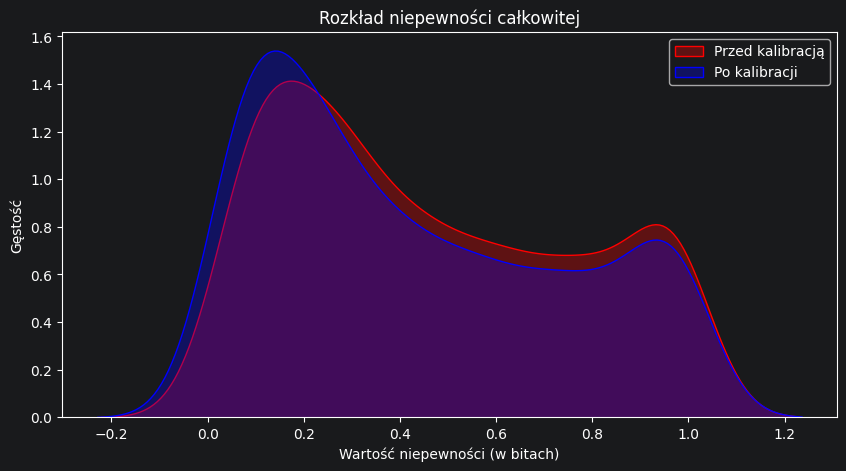

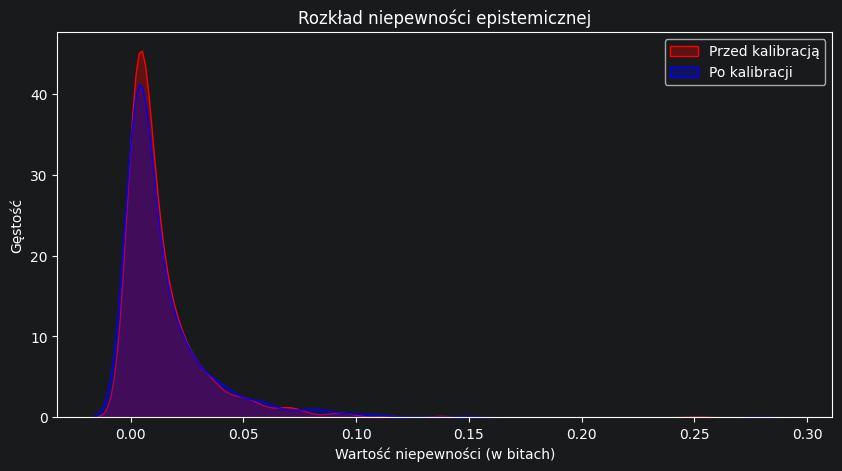

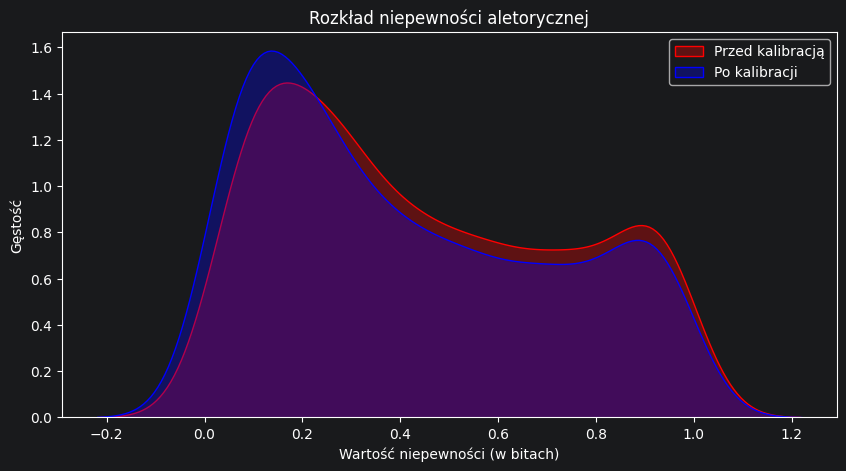

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns


total_bef, epistemic_bef, aleatoric_bef = calculate_uncertainties(probs['before'])
total_aft, epistemic_aft, aleatoric_aft = calculate_uncertainties(probs['after'])


plt.figure(figsize=(10, 5))
sns.kdeplot(total_bef, label="Przed kalibracją", color="red", fill=True, alpha=0.3)
sns.kdeplot(total_aft, label="Po kalibracji", color="blue", fill=True, alpha=0.3)
plt.title("Rozkład niepewności całkowitej")
plt.xlabel("Wartość niepewności (w bitach)")
plt.ylabel("Gęstość")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(epistemic_bef, label="Przed kalibracją", color="red", fill=True, alpha=0.3)
sns.kdeplot(epistemic_aft, label="Po kalibracji", color="blue", fill=True, alpha=0.3)
plt.title("Rozkład niepewności epistemicznej")
plt.xlabel("Wartość niepewności (w bitach)")
plt.ylabel("Gęstość")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(aleatoric_bef, label="Przed kalibracją", color="red", fill=True, alpha=0.3)
sns.kdeplot(aleatoric_aft, label="Po kalibracji", color="blue", fill=True, alpha=0.3)
plt.title("Rozkład niepewności aletorycznej")
plt.xlabel("Wartość niepewności (w bitach)")
plt.ylabel("Gęstość")
plt.legend()
plt.show()